# Compute shifted border scores — all COHORT12 mice/days

Generates `shifted_border_score.parquet` in `<session>/tuning_scores/` for every
mouse × day × session (OF1, OF2) in COHORT12.

**Border score** follows Solstad et al. (2008):  
  `BS = (C_max - d_mean) / (C_max + d_mean)`

where C_max is the maximum wall coverage (fraction of wall-adjacent bins with firing
rate > 30% of peak) and d_mean is the mean normalised distance of field pixels from
the nearest wall.

**Position shift (travel lag):**  
Position is projected along the path at lags `−50 … +49 cm` (1 cm steps) using
`compute_travel_projected`. At lag 0, 200 circular-shift shuffles are computed to
generate the null distribution; the 95th percentile is used as the significance
threshold for all lags.

Output schema (one row per cluster × travel):
```
cluster_id, brain_region, border_score, travel, sig,
null_border_score  (list[float] at travel==0, else None)
```

Sessions that already have the output file are **skipped**.

In [1]:
import os
import numpy as np
import pandas as pd
import pynapple as nap
import warnings
warnings.filterwarnings('ignore')

from spatial_manifolds.predictive_grid import compute_travel_projected
from spatial_manifolds.detect_grids import curate_clusters
from spatial_manifolds.tuning_scores.border_score import (
    border_score_from_rate_map, compute_rate_map
)

source_path = '/Users/harryclark/Downloads/COHORT12/'

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

SESSIONS        = ['OF1', 'OF2']
TRAVEL_VALUES   = np.arange(-50, 50, 1)   # -50 … +49 cm, 100 values
N_SHUFFLES      = 200
N_BINS          = 40
SIGMA           = 2.0    # Gaussian smoothing in bins
ARENA_MIN       = 0.0
ARENA_MAX       = 100.0
ALPHA           = 0.05   # → 95th percentile of null
OVERWRITE       = False  # set True to recompute existing files

# Brain-region lookup (used by detect_grids for all other scores)
brain_loc_path = source_path + 'all_cluster_brain_locations_chris.csv'
brain_locations = pd.read_csv(brain_loc_path) if os.path.exists(brain_loc_path) else None

def get_brain_region(mouse, day, cluster_id):
    if brain_locations is None:
        return 'unknown'
    row = brain_locations[
        (brain_locations['mouse'] == mouse) &
        (brain_locations['day']   == day)   &
        (brain_locations['cluster_id'] == cluster_id)
    ]
    return row['brain_region'].iloc[0] if len(row) else 'unknown'

print('Config ready.')
print(f'Travel range: {TRAVEL_VALUES[0]} to {TRAVEL_VALUES[-1]} cm  ({len(TRAVEL_VALUES)} values)')

Config ready.
Travel range: -50 to 49 cm  (100 values)


---
## Sanity check — M29 D23

Run both OF sessions for a single well-characterised recording before committing to the full cohort.  
Shows rate maps for:
- **border cells** (sig at travel = 0, top by border score)  
- **non-border cells** (random sample)

Visually confirm that high-scoring cells have wall-hugging firing fields before running the main loop.


── M29 D23 OF1 ──
  Cells: 211   Border cells (sig): 31
 cluster_id  border_score  sig  sig_thresh                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

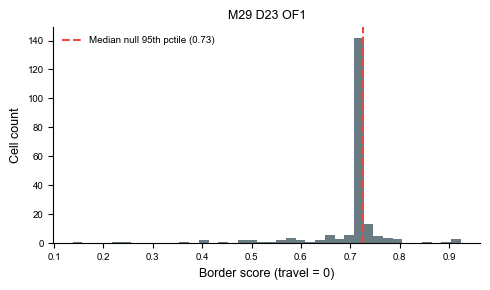

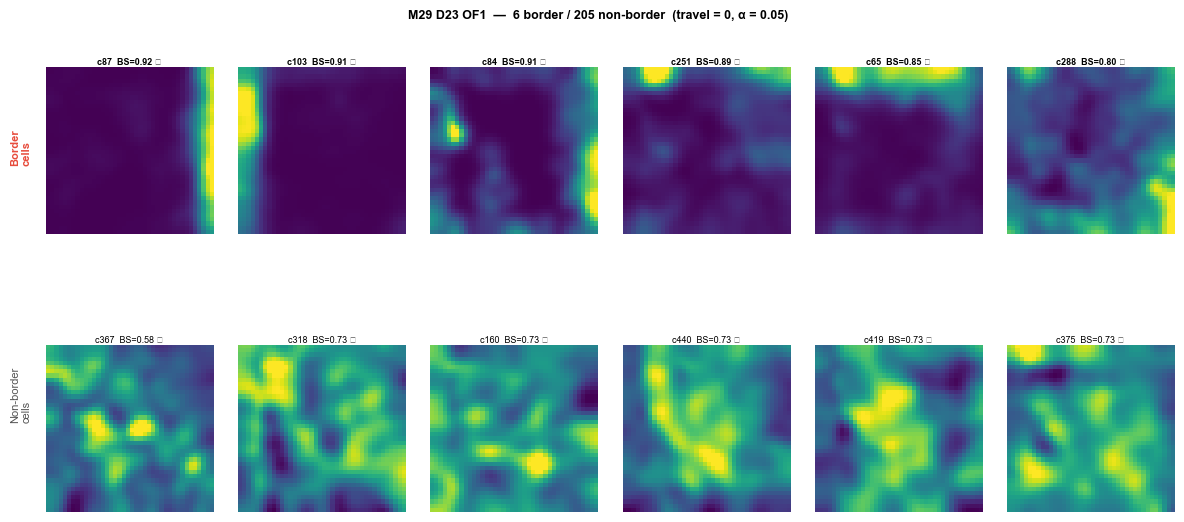


── M29 D23 OF2 ──
  Cells: 211   Border cells (sig): 39
 cluster_id  border_score  sig  sig_thresh                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

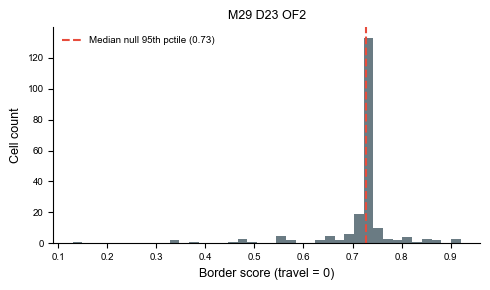

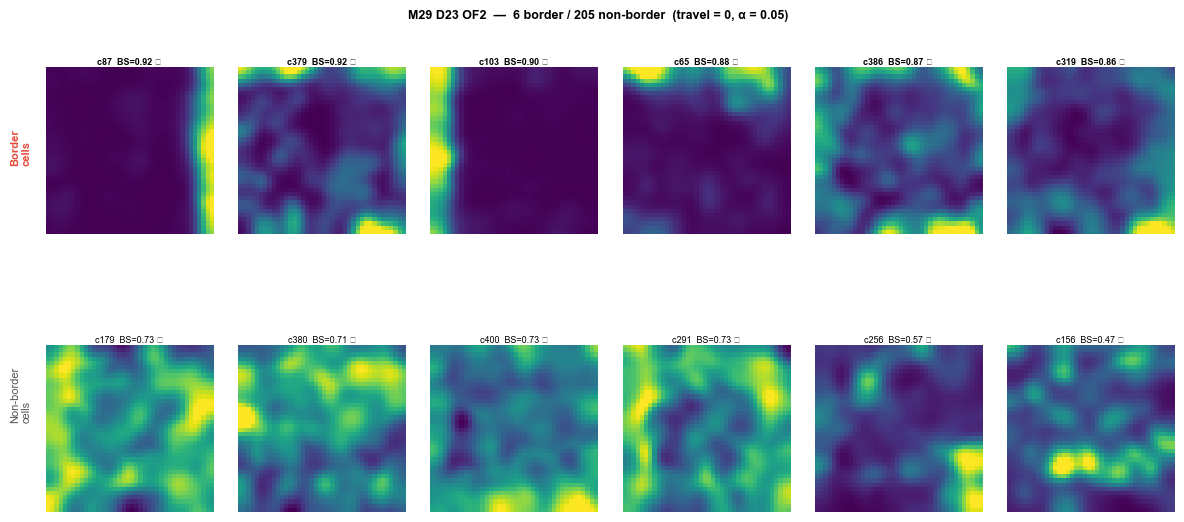


Sanity check complete. Inspect rate maps above before running the main loop.


In [2]:
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

SANITY_MOUSE   = 29
SANITY_DAY     = 23
SANITY_SESSIONS = ['OF1', 'OF2']
N_SHOW_BORDER  = 6   # top border cells to show per session
N_SHOW_NON     = 6   # random non-border cells to show per session

np.random.seed(42)

def _run_session(mouse, day, session):
    """Run border score at travel=0 with full shuffle null for one session.
    Returns (rows_df, rate_maps_dict, sig_thresh_dict)."""
    sf = f'{source_path}M{mouse}/D{day:02}/{session}/'
    beh      = nap.load_file(sf + f'sub-{mouse}_day-{day:02}_ses-{session}_beh.nwb')
    clusters = curate_clusters(nap.load_file(
        sf + f'sub-{mouse}_day-{day:02}_ses-{session}_srt-kilosort4_clusters.npz'
    ))
    pos_times = np.array(beh['P_x'].times())
    pos_x_raw = np.array(beh['P_x'])
    pos_y_raw = np.array(beh['P_y'])

    last_bin = clusters[clusters.index[0]].count(bin_size=10, time_units='ms').index[-1]
    ep = nap.IntervalSet(start=0, end=last_bin, time_units='s')

    rows, rate_maps, sig_thresholds = [], {}, {}

    for cid in clusters.index:
        spike_times = np.array(clusters[cid].restrict(ep).t)

        # Null distribution (travel = 0)
        null_scores = []
        for _ in range(N_SHUFFLES):
            shuf = np.array(nap.shift_timestamps(clusters[cid].restrict(ep), min_shift=20.0).t)
            rm_sh = compute_rate_map(shuf, pos_x_raw, pos_y_raw, pos_times,
                                     n_bins=N_BINS, arena_min=ARENA_MIN,
                                     arena_max=ARENA_MAX, sigma=SIGMA)
            null_scores.append(border_score_from_rate_map(rm_sh))
        null_arr   = np.array(null_scores, dtype=float)
        sig_thresh = np.nanpercentile(null_arr, 100 * (1 - ALPHA))
        sig_thresholds[cid] = sig_thresh

        # Real rate map at travel = 0
        rm = compute_rate_map(spike_times, pos_x_raw, pos_y_raw, pos_times,
                              n_bins=N_BINS, arena_min=ARENA_MIN,
                              arena_max=ARENA_MAX, sigma=SIGMA)
        rate_maps[cid] = rm
        bs = border_score_from_rate_map(rm)

        rows.append(dict(
            cluster_id=int(cid),
            border_score=float(bs) if np.isfinite(bs) else np.nan,
            sig=bool(np.isfinite(bs) and bs > sig_thresh),
            sig_thresh=float(sig_thresh),
            null_border_score=null_arr.tolist(),
        ))

    return pd.DataFrame(rows), rate_maps, sig_thresholds


def _plot_session(df, rate_maps, session_label):
    """Plot border + non-border cells with rate maps."""
    border_ids = df[df['sig']].sort_values('border_score', ascending=False)['cluster_id'].values
    non_border_ids = df[~df['sig']].dropna(subset=['border_score'])['cluster_id'].values
    np.random.shuffle(non_border_ids)

    show_border  = list(border_ids[:N_SHOW_BORDER])
    show_non     = list(non_border_ids[:N_SHOW_NON])

    n_b  = len(show_border)
    n_nb = len(show_non)
    n_cols = max(n_b, n_nb, 1)

    fig = plt.figure(figsize=(n_cols * 2.0, 5.5))
    gs  = gridspec.GridSpec(2, n_cols, figure=fig, hspace=0.60, wspace=0.15,
                            left=0.04, right=0.98, top=0.88, bottom=0.06)

    def _plot_rm(ax, cid, row_df):
        rm  = rate_maps[cid]
        row = row_df[row_df['cluster_id'] == cid].iloc[0]
        vmax = np.nanpercentile(rm, 99) if not np.all(np.isnan(rm)) else 1.0
        vmin = np.nanmin(rm) if not np.all(np.isnan(rm)) else 0.0
        ax.imshow(rm.T, origin='lower', aspect='equal',
                  cmap='viridis', vmin=vmin, vmax=vmax)
        sig_str = '✓' if row['sig'] else '✗'
        ax.set_title(f'c{cid}  BS={row["border_score"]:.2f} {sig_str}',
                     fontsize=6.5, fontweight='bold' if row['sig'] else 'normal', pad=2)
        ax.axis('off')

    # Row 0: border cells
    for ci, cid in enumerate(show_border):
        _plot_rm(fig.add_subplot(gs[0, ci]), cid, df)
    if n_b == 0:
        fig.add_subplot(gs[0, 0]).text(0.5, 0.5, 'No border cells', ha='center',
                                        va='center', transform=fig.add_subplot(gs[0, 0]).transAxes)

    # Row 1: non-border cells
    for ci, cid in enumerate(show_non):
        _plot_rm(fig.add_subplot(gs[1, ci]), cid, df)

    # Row labels
    fig.text(0.01, 0.73, 'Border\ncells', va='center', ha='left',
             fontsize=8, fontweight='bold', color='#e74c3c', rotation=90)
    fig.text(0.01, 0.28, 'Non-border\ncells', va='center', ha='left',
             fontsize=8, color='#555555', rotation=90)

    fig.suptitle(
        f'M{SANITY_MOUSE} D{SANITY_DAY} {session_label}  —  '
        f'{n_b} border / {len(df) - n_b} non-border  (travel = 0, α = {ALPHA})',
        fontsize=9, fontweight='bold'
    )
    plt.show()
    return n_b


def _plot_score_hist(df, session_label):
    """Distribution of border scores vs per-cell null threshold."""
    fig, ax = plt.subplots(figsize=(5, 3))
    scores = df['border_score'].dropna()
    ax.hist(scores, bins=40, color='#455A64', edgecolor='none', alpha=0.8)

    # Median null threshold
    med_thresh = df['sig_thresh'].median()
    ax.axvline(med_thresh, color='#e74c3c', lw=1.5, ls='--',
               label=f'Median null 95th pctile ({med_thresh:.2f})')
    ax.set_xlabel('Border score (travel = 0)', fontsize=9)
    ax.set_ylabel('Cell count', fontsize=9)
    ax.set_title(f'M{SANITY_MOUSE} D{SANITY_DAY} {session_label}', fontsize=9)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()


# ── Run for each session ──────────────────────────────────────────────────────
for ses in SANITY_SESSIONS:
    print(f'\n── M{SANITY_MOUSE} D{SANITY_DAY} {ses} ──')
    df_s, rms_s, _ = _run_session(SANITY_MOUSE, SANITY_DAY, ses)
    n_border = df_s['sig'].sum()
    print(f'  Cells: {len(df_s)}   Border cells (sig): {n_border}')
    print(df_s.sort_values('border_score', ascending=False).head(8).to_string(index=False))
    _plot_score_hist(df_s, ses)
    _plot_session(df_s, rms_s, ses)

print('\nSanity check complete. Inspect rate maps above before running the main loop.')

## Main loop

For each mouse × day × session:
1. Load spikes + behaviour
2. For each cluster, compute null distribution (200 shuffles at travel = 0)
3. For each travel lag, shift position and compute border score
4. Save `shifted_border_score.parquet`

In [3]:
total_saved = 0
total_skipped = 0

for mouse, days in mouse_days.items():
    for day in days:
        for session in SESSIONS:

            session_folder = f'{source_path}M{mouse}/D{day:02}/{session}/'
            out_path = session_folder + 'tuning_scores/shifted_border_score.parquet'

            if not os.path.isdir(session_folder):
                continue

            if os.path.exists(out_path) and not OVERWRITE:
                print(f'  SKIP  M{mouse} D{day} {session}  (already exists)')
                total_skipped += 1
                continue

            spikes_path = (session_folder +
                           f'sub-{mouse}_day-{day:02}_ses-{session}_srt-kilosort4_clusters.npz')
            beh_path    = (session_folder +
                           f'sub-{mouse}_day-{day:02}_ses-{session}_beh.nwb')

            if not os.path.exists(spikes_path) or not os.path.exists(beh_path):
                print(f'  MISS  M{mouse} D{day} {session}  (data files not found)')
                continue

            try:
                beh      = nap.load_file(beh_path)
                clusters = nap.load_file(spikes_path)
                clusters = curate_clusters(clusters)
            except Exception as e:
                print(f'  ERR   M{mouse} D{day} {session}  load failed: {e}')
                continue

            # Raw position arrays
            pos_times = np.array(beh['P_x'].times())
            pos_x_raw = np.array(beh['P_x'])
            pos_y_raw = np.array(beh['P_y'])
            position  = np.stack([beh['P_x'], beh['P_y']], axis=1)

            # End epoch from last spike bin of the busiest cell
            last_bin = clusters[clusters.index[0]].count(
                bin_size=10, time_units='ms'
            ).index[-1]
            ep = nap.IntervalSet(start=0, end=last_bin, time_units='s')

            rows = []
            cluster_ids = list(clusters.index)
            print(f'  RUN   M{mouse} D{day} {session}  — {len(cluster_ids)} cells', end='  ')

            for cid in cluster_ids:
                spike_times = np.array(clusters[cid].restrict(ep).t)

                brain_region = get_brain_region(mouse, day, cid)

                # ── Null distribution at travel = 0 ───────────────────────────
                null_scores = []
                for _ in range(N_SHUFFLES):
                    shuffled = np.array(
                        nap.shift_timestamps(clusters[cid].restrict(ep),
                                             min_shift=20.0).t
                    )
                    rm_sh = compute_rate_map(
                        shuffled, pos_x_raw, pos_y_raw, pos_times,
                        n_bins=N_BINS,
                        arena_min=ARENA_MIN, arena_max=ARENA_MAX,
                        sigma=SIGMA,
                    )
                    null_scores.append(border_score_from_rate_map(rm_sh))

                null_arr   = np.array(null_scores, dtype=float)
                sig_thresh = np.nanpercentile(null_arr, 100 * (1 - ALPHA))

                # ── Score at each travel lag ──────────────────────────────────
                for travel in TRAVEL_VALUES:
                    if travel == 0:
                        px_t = pos_x_raw
                        py_t = pos_y_raw
                    else:
                        beh_lag = compute_travel_projected(
                            ['P_x', 'P_y'], position, position, float(travel)
                        )
                        px_t = np.array(beh_lag['P_x'])
                        py_t = np.array(beh_lag['P_y'])
                        pos_times_t = np.array(beh_lag['P_x'].times())

                    pt = pos_times if travel == 0 else pos_times_t
                    rm = compute_rate_map(
                        spike_times, px_t, py_t, pt,
                        n_bins=N_BINS,
                        arena_min=ARENA_MIN, arena_max=ARENA_MAX,
                        sigma=SIGMA,
                    )
                    bs = border_score_from_rate_map(rm)

                    rows.append(dict(
                        cluster_id=int(cid),
                        brain_region=brain_region,
                        border_score=float(bs) if np.isfinite(bs) else float('nan'),
                        travel=int(travel),
                        sig=bool(np.isfinite(bs) and bs > sig_thresh),
                        null_border_score=null_arr.tolist() if travel == 0 else None,
                    ))

            df = pd.DataFrame(rows)
            os.makedirs(session_folder + 'tuning_scores', exist_ok=True)
            df.to_parquet(out_path, index=False)
            total_saved += 1
            n_sig = df[(df['travel'] == 0) & df['sig']]['cluster_id'].nunique()
            print(f'saved  ({n_sig}/{len(cluster_ids)} sig at lag 0)')

print(f'\nDone.  Saved: {total_saved}   Skipped: {total_skipped}')

  RUN   M20 D14 OF1  — 204 cells  saved  (6/204 sig at lag 0)
  RUN   M20 D14 OF2  — 204 cells  

KeyboardInterrupt: 